### Лабораторная работа №6: Использование методов нечеткой логики для классификации объектов по информации о них, хранящейся в интеллектуальной базе данных


In [28]:
%pip install mysql-connector-python numpy matplotlib

### Получение и нормализация данных из БД MySQL

In [29]:
import mysql.connector
from mysql.connector import Error
import numpy as np
import matplotlib.pyplot as plt

db_data = []

try:
    connection = mysql.connector.connect(
        host='localhost',
        port=3306,
        user='root',
        password='rootpassword',
        database='telecom_db'
    )
    
    if connection.is_connected():
        print("Успешное подключение к MySQL базе данных!")

        query = """
            SELECT 
                s.sub_name,
                SUM(c.c_duration) as total_duration,
                COUNT(c.call_ID) as total_calls
            FROM Subscribers s
            JOIN Calls c ON s.sub_ID = c.c_sub_ID
            GROUP BY s.sub_ID
            ORDER BY s.sub_name;
        """
        
        with connection.cursor() as cursor:
            cursor.execute(query)
            records = cursor.fetchall()
            
            for i, row in enumerate(records):
                sub_name = row[0]
                # Нормализация
                norm_duration = max(0.0, min(10.0, float(row[1]) / 12.0))
                norm_calls = max(0.0, min(10.0, float(row[2]) * 2.0))
                
                db_data.append({
                    'id': i + 1,
                    'name': sub_name, 
                    'norm_duration': norm_duration, 
                    'norm_calls': norm_calls
                })
except Error as e:
    print(f"Ошибка при подключении к MySQL: {e}")
finally:
    if 'connection' in locals() and connection.is_connected():
        connection.close()

db_data

Успешное подключение к MySQL базе данных!


[{'id': 1,
  'name': 'АО "Интеграл"',
  'norm_duration': 2.5833333333333335,
  'norm_calls': 4.0},
 {'id': 2, 'name': 'АО "Омега"', 'norm_duration': 10.0, 'norm_calls': 10.0},
 {'id': 3,
  'name': 'ЗАО "Авангард"',
  'norm_duration': 2.6666666666666665,
  'norm_calls': 4.0},
 {'id': 4,
  'name': 'ЗАО "Бета-Торг"',
  'norm_duration': 0.75,
  'norm_calls': 4.0},
 {'id': 5,
  'name': 'ЗАО "Вектор"',
  'norm_duration': 3.6666666666666665,
  'norm_calls': 4.0},
 {'id': 6,
  'name': 'ИП Иванов А.А.',
  'norm_duration': 0.6666666666666666,
  'norm_calls': 2.0},
 {'id': 7,
  'name': 'ИП Петров В.С.',
  'norm_duration': 0.5833333333333334,
  'norm_calls': 2.0},
 {'id': 8, 'name': 'ИП Сидоров А.В.', 'norm_duration': 3.5, 'norm_calls': 2.0},
 {'id': 9, 'name': 'ООО "Альфа"', 'norm_duration': 10.0, 'norm_calls': 10.0},
 {'id': 10,
  'name': 'ООО "Горизонт"',
  'norm_duration': 0.6666666666666666,
  'norm_calls': 2.0},
 {'id': 11,
  'name': 'ООО "Дельта-IT"',
  'norm_duration': 1.25,
  'norm_calls'

### Построение графиков нечетких множеств для входных переменных (по Гауссу)

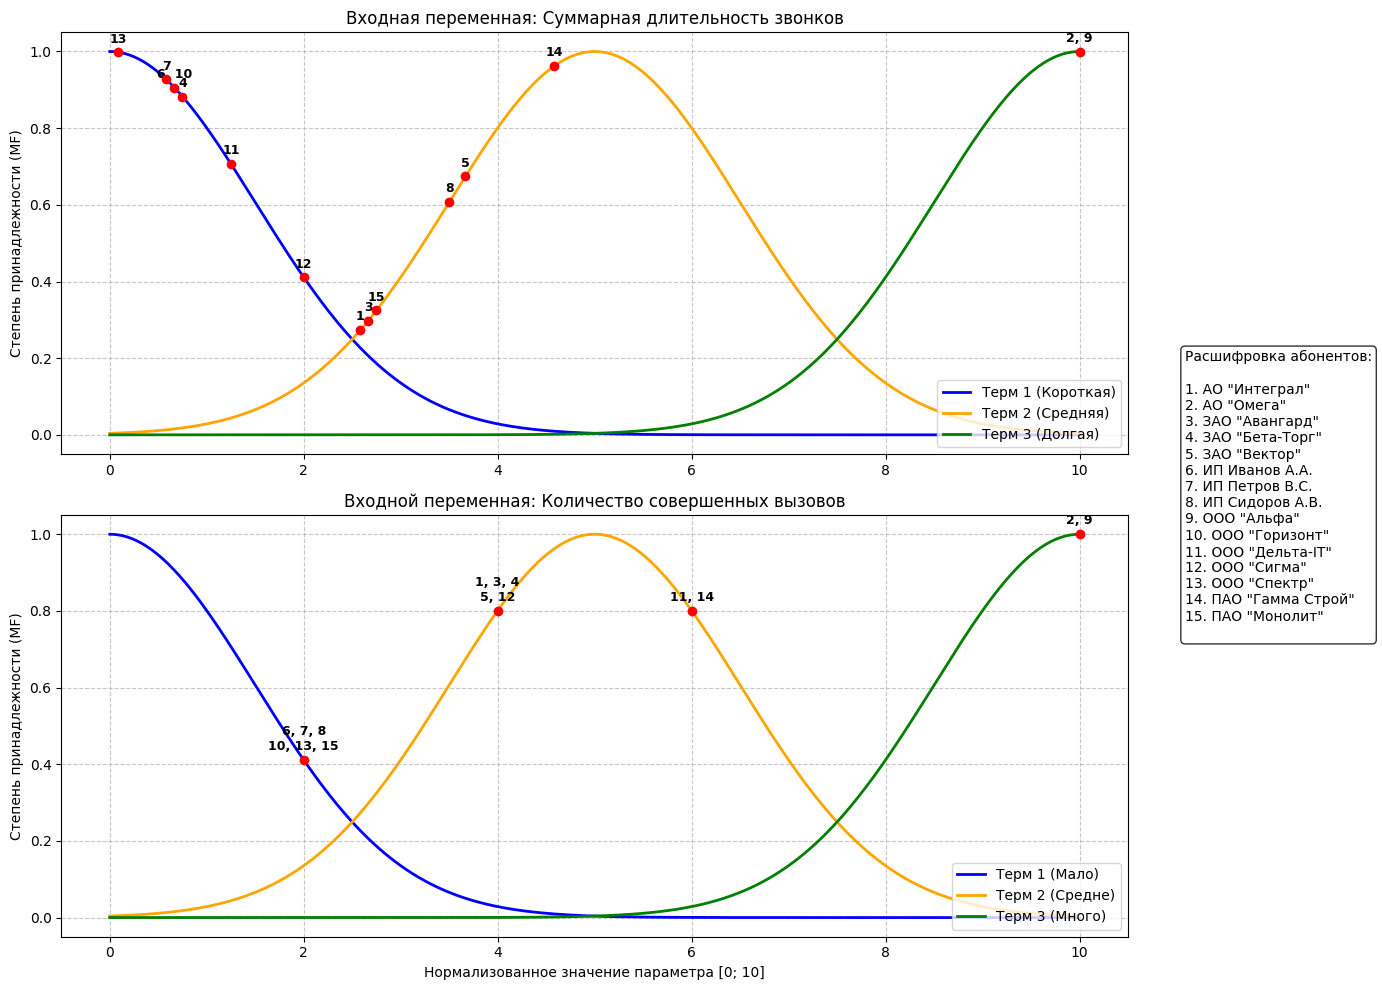

In [30]:
# Универсальная функция для расчета максимальной степени принадлежности
def get_max_mf(x_val):
    return max(
        np.exp(-(x_val**2) / 4.5), 
        np.exp(-((x_val - 5)**2) / 4.5), 
        np.exp(-((x_val - 10)**2) / 4.5)
    )

# Функция для отрисовки точек с группировкой накладывающихся подписей
def plot_grouped_points(ax, data, key_nx):
    points_dict = {}
    
    # Группируем ID по координатам (округляем до 3 знаков для надежности)
    for d in data:
        nx = d[key_nx]
        my = get_max_mf(nx)
        coord = (round(nx, 3), round(my, 3))
        
        if coord not in points_dict:
            points_dict[coord] = []
        points_dict[coord].append(str(d['id']))
        
    # Отрисовываем сгруппированные точки
    for (nx, my), ids in points_dict.items():
        ax.scatter(nx, my, color='red', zorder=5)
        
        # Если абонентов в одной точке много (больше 3), разбиваем их на несколько строк
        chunks = [", ".join(ids[i:i+3]) for i in range(0, len(ids), 3)]
        text_label = "\n".join(chunks)
        
        ax.annotate(text_label, (nx, my), textcoords="offset points", 
                    xytext=(0,7), ha='center', fontsize=9, fontweight='bold')

x = np.linspace(0, 10, 500)
y_blue = np.exp(-(x**2) / 4.5)
y_orange = np.exp(-((x - 5)**2) / 4.5)
y_green = np.exp(-((x - 10)**2) / 4.5)

# Создаем окно с двумя подграфиками (2 строки, 1 столбец)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# --- График 1: Длительность звонков ---
ax1.plot(x, y_blue, label='Терм 1 (Короткая)', color='blue', linewidth=2)
ax1.plot(x, y_orange, label='Терм 2 (Средняя)', color='orange', linewidth=2)
ax1.plot(x, y_green, label='Терм 3 (Долгая)', color='green', linewidth=2)

plot_grouped_points(ax1, db_data, 'norm_duration')

ax1.set_title('Входная переменная: Суммарная длительность звонков')
ax1.set_ylabel('Степень принадлежности (MF)')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc='lower right')

# --- График 2: Количество звонков ---
ax2.plot(x, y_blue, label='Терм 1 (Мало)', color='blue', linewidth=2)
ax2.plot(x, y_orange, label='Терм 2 (Средне)', color='orange', linewidth=2)
ax2.plot(x, y_green, label='Терм 3 (Много)', color='green', linewidth=2)

plot_grouped_points(ax2, db_data, 'norm_calls')

ax2.set_title('Входной переменная: Количество совершенных вызовов')
ax2.set_xlabel('Нормализованное значение параметра [0; 10]')
ax2.set_ylabel('Степень принадлежности (MF)')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='lower right')

# --- Формирование легенды с именами абонентов (справа от графиков) ---
legend_text = "Расшифровка абонентов:\n\n"
for d in db_data:
    legend_text += f"{d['id']}. {d['name']}\n"

# Размещаем текст справа
plt.figtext(0.85, 0.5, legend_text, fontsize=10, va="center", 
            bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8})

# Сдвигаем графики влево, чтобы освободить место для текста
plt.subplots_adjust(right=0.8)

plt.tight_layout(rect=[0, 0, 0.82, 1]) # Ограничиваем область графиков
plt.show()

### Построение графика нечеткого множества для выходной переменной (по Гауссу)

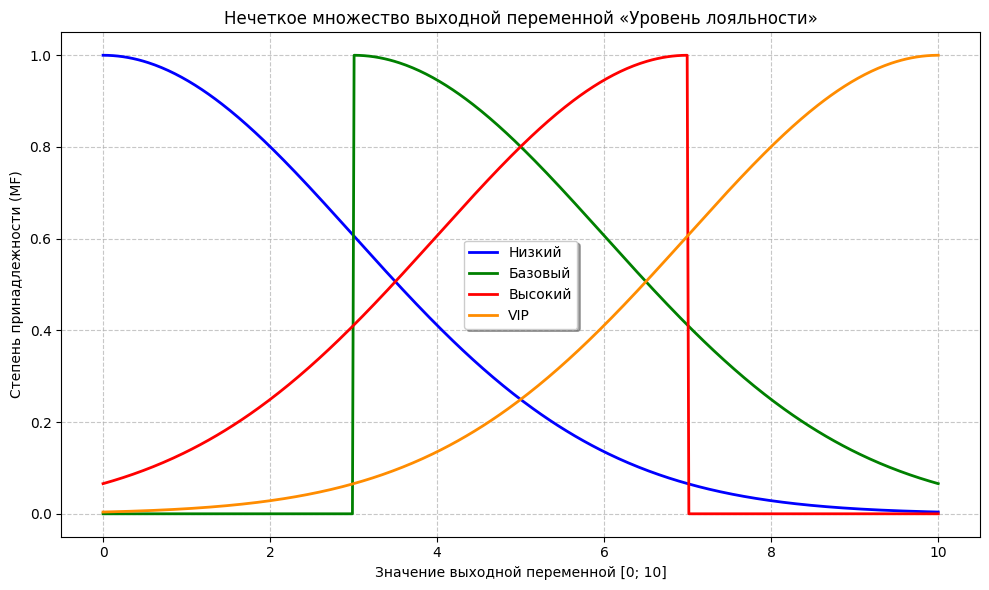

In [31]:
# Задаем ось X в диапазоне [0; 10]
x = np.linspace(0, 10, 500)

# 1. Функция для терма «Низкий» (синий график)
# Убывающая функция на всем интервале
y_low = np.exp(-(x**2) / 18)

# 2. Функция для терма «Базовый» (зеленый график)
# Кусочно-заданная: 0 до x=3, убывающая после x=3
y_base = np.where(x < 3, 0, np.exp(-((x - 3)**2) / 18))

# 3. Функция для терма «Высокий» (красный график)
# Кусочно-заданная: возрастающая до x=7, 0 после x=7
y_high = np.where(x > 7, 0, np.exp(-((x - 7)**2) / 18))

# 4. Функция для терма «VIP» (оранжевый график)
# Возрастающая функция на всем интервале
y_vip = np.exp(-((x - 10)**2) / 18)

# Настройка и отрисовка графика
plt.figure(figsize=(10, 6))

plt.plot(x, y_low, label='Низкий', color='blue', linewidth=2)
plt.plot(x, y_base, label='Базовый', color='green', linewidth=2)
plt.plot(x, y_high, label='Высокий', color='red', linewidth=2)
plt.plot(x, y_vip, label='VIP', color='darkorange', linewidth=2)

plt.title('Нечеткое множество выходной переменной «Уровень лояльности»')
plt.xlabel('Значение выходной переменной [0; 10]')
plt.ylabel('Степень принадлежности (MF)')

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='center', bbox_to_anchor=(0.5, 0.5), shadow=True)

plt.tight_layout()
plt.show()

### Реализация алгоритма определения класса

In [ ]:
# Параметры подключения к MySQL в Docker
DB_CONFIG = {
    'host': 'localhost',
    'port': 3306,
    'user': 'root',
    'password': 'rootpassword',
    'database': 'telecom_db'
}

# База правил: [Индекс x1, Индекс x2, Индекс Выхода]
# Индексы: 0-Короткая/Мало/Низкий, 1-Средняя/Средне/Базовый, 
#          2-Долгая/Много/Высокий, 3-VIP
RULES = [
    (0, 0, 0), (0, 1, 1), (0, 2, 1),
    (1, 0, 1), (1, 1, 2), (1, 2, 2),
    (2, 0, 2), (2, 1, 3), (2, 2, 3)
]

# Входные функции (Гаусс, sigma=1.5, mu={0, 5, 10})
def mf_input(x, mu):
    return np.exp(-((x - mu)**2) / 4.5)

# Обратные выходные функции (для поиска z в алгоритме Цукамото)
# Используем mu={0, 3, 7, 10} и sigma=3 (2*sigma^2 = 18)
def imf_output(alpha, mu, direction='right'):
    if alpha <= 0: return mu
    val = np.sqrt(-18 * np.log(alpha))
    return mu + val if direction == 'right' else mu - val

# Прямые выходные функции (для финальной проверки класса)
def mf_output(z, mu, logic=None):
    if logic == 'base' and z < 3: return 0
    if logic == 'high' and z > 7: return 0
    return np.exp(-((z - mu)**2) / 18)


def run_classification():
    try:
        conn = mysql.connector.connect(**DB_CONFIG)
        if not conn.is_connected(): return
        
        cursor = conn.cursor()
        # Агрегация данных в SQL
        cursor.execute("""
            SELECT s.sub_name, SUM(c.c_duration), COUNT(c.call_ID)
            FROM Subscribers s
            JOIN Calls c ON s.sub_ID = c.c_sub_ID
            GROUP BY s.sub_ID
        """)
        
        print(f"{'Абонент':<25} | {'z0':<6} | {'Результат'}")
        print("-" * 50)

        for name, duration, count in cursor:
            # 1. Нормализация к [0; 10]
            x1 = max(0.0, min(10.0, float(duration) / 12.0))
            x2 = max(0.0, min(10.0, float(count) * 2.0))

            # 2. Фаззификация (степени принадлежности термам)
            mu_x1 = [mf_input(x1, 0), mf_input(x1, 5), mf_input(x1, 10)]
            mu_x2 = [mf_input(x2, 0), mf_input(x2, 5), mf_input(x2, 10)]

            # 3. Логический вывод (Цукамото)
            numerator, denominator = 0.0, 0.0
            
            for idx1, idx2, out_idx in RULES:
                # Находим альфа (минимум по "И")
                alpha = min(mu_x1[idx1], mu_x2[idx2])
                
                # Находим z (аргумент выходной функции)
                if out_idx == 0: z = imf_output(alpha, 0, 'right')
                elif out_idx == 1: z = imf_output(alpha, 3, 'right')
                elif out_idx == 2: z = imf_output(alpha, 7, 'left')
                else: z = imf_output(alpha, 10, 'left')
                
                z = max(0.0, min(10.0, z))

                # Центроидный метод
                numerator += alpha * z
                denominator += alpha

            if denominator == 0: continue
            z0 = numerator / denominator

            # 4. Дефаззификация (определение итогового класса по максимуму MF)
            classes = ["Низкий", "Базовый", "Высокий", "VIP"]
            scores = [
                mf_output(z0, 0), 
                mf_output(z0, 3, 'base'), 
                mf_output(z0, 7, 'high'), 
                mf_output(z0, 10)
            ]
            final_class = classes[np.argmax(scores)]
            
            print(f"{name:<25} | {z0:<6.2f} | {final_class}")

    except Error as e:
        print(f"Ошибка БД: {e}")
    finally:
        if 'conn' in locals() and conn.is_connected():
            conn.close()

if __name__ == "__main__":
    run_classification()

Абонент                   | z0     | Результат
--------------------------------------------------
ООО "Альфа"               | 9.89   | VIP
ЗАО "Бета-Торг"           | 5.10   | Высокий
ПАО "Гамма Строй"         | 4.93   | Базовый
ИП Иванов А.А.            | 5.23   | Высокий
ООО "Дельта-IT"           | 5.17   | Высокий
АО "Омега"                | 9.89   | VIP
ООО "Сигма"               | 5.84   | Высокий
ИП Петров В.С.            | 5.23   | Высокий
ЗАО "Вектор"              | 5.04   | Высокий
ПАО "Монолит"             | 6.16   | Высокий
ООО "Спектр"              | 5.23   | Высокий
ИП Сидоров А.В.           | 6.09   | Высокий
АО "Интеграл"             | 5.31   | Высокий
ООО "Горизонт"            | 5.23   | Высокий
ЗАО "Авангард"            | 5.21   | Высокий
